core           INFO 	Loading data for Japanese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '2

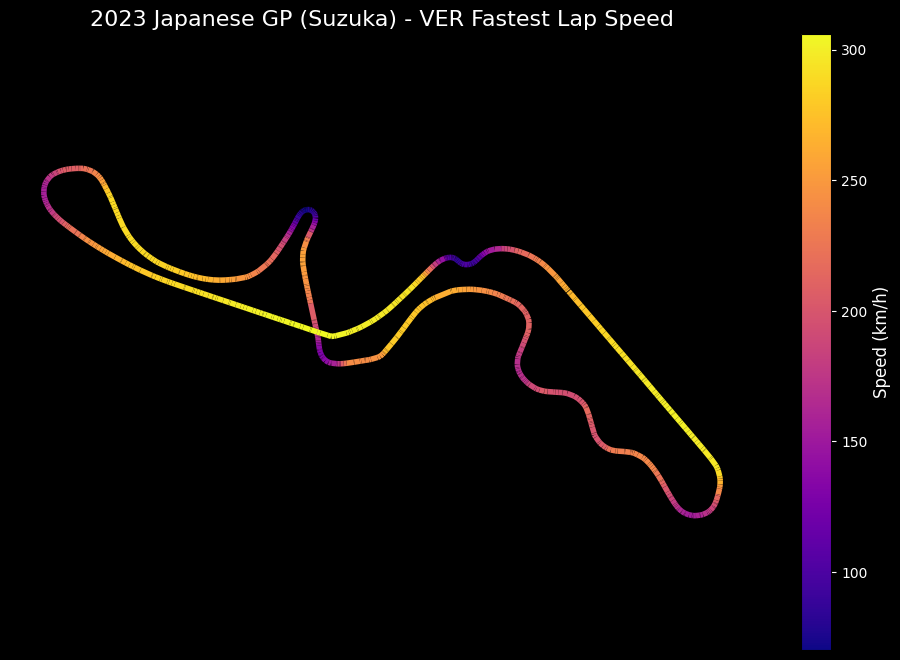

In [1]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
import numpy as np

# 1. 설정 및 데이터 로드
fastf1.Cache.enable_cache('../fastf1_cache')  # 캐시 경로 유지

# 2023 일본 GP 레이스 세션 로드
session = fastf1.get_session(2023, 'Japanese Grand Prix', 'R')
session.load()

# 가장 빠른 랩(Fastest Lap)을 기준으로 트랙 형상 추출
lap = session.laps.pick_fastest()
telemetry = lap.get_telemetry()

# 2. 데이터 준비 (X, Y 좌표 및 속도)
x = telemetry['X']              # X 좌표
y = telemetry['Y']              # Y 좌표
speed = telemetry['Speed']      # 속도 (색상 기준)

# 3. 시각화 (LineCollection 사용)
# 트랙을 여러 개의 짧은 선분(Segment)으로 나누어 각 구간의 속도에 따라 색을 입힙니다.

# (1) 점들을 선분으로 연결하기 위한 데이터 구조 변환
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# (2) 그래프 설정
fig, ax = plt.subplots(figsize=(12, 8), facecolor='black') # 배경 검은색
ax.set_facecolor('black')

# (3) 컬러맵 설정 (속도가 빠를수록 밝은색/노란색, 느릴수록 어두운색/보라색)
cmap = plt.get_cmap('plasma') 

# (4) LineCollection 생성 및 추가
lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(speed.min(), speed.max()))
lc.set_array(speed)
lc.set_linewidth(4)  # 선 두께

line = ax.add_collection(lc)

# (5) 축 및 타이틀 설정
ax.axis('equal')  # 트랙 비율 유지 (찌그러짐 방지)
ax.set_title(f"2023 Japanese GP (Suzuka) - {lap['Driver']} Fastest Lap Speed", 
             color='white', fontsize=16)

# 축 눈금 제거 (깔끔하게)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# (6) 컬러바 추가
cbar = plt.colorbar(line, ax=ax, pad=0.05)
cbar.set_label('Speed (km/h)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '22', '24', '27', '20', '23', '2', '18', '11', '77']


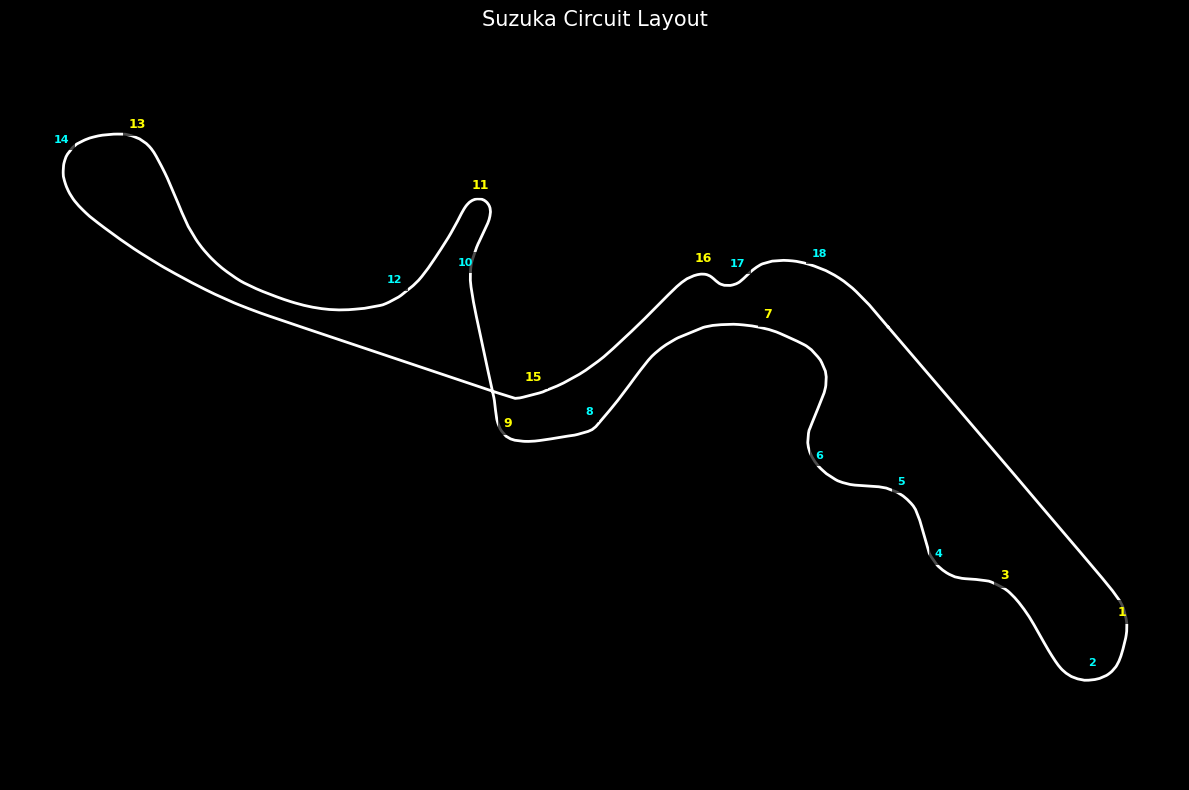

In [5]:
import fastf1
import matplotlib.pyplot as plt
import numpy as np

# 1. 설정 및 데이터 로드
fastf1.Cache.enable_cache('../fastf1_cache')
session = fastf1.get_session(2023, 'Japanese Grand Prix', 'R')
session.load()

# 2. 트랙 형상 데이터 (가장 빠른 랩 기준)
lap = session.laps.pick_fastest()
telemetry = lap.get_telemetry()
track_x = telemetry['X']
track_y = telemetry['Y']

# 3. 코너 정보 가져오기 (FastF1 내장 기능)
circuit_info = session.get_circuit_info()

# 4. 시각화
fig, ax = plt.subplots(figsize=(12, 8), facecolor='black')
ax.set_facecolor('black')

# (1) 트랙 라인 그리기 (흰색 실선)
ax.plot(track_x, track_y, color='white', linewidth=2, label='Track Layout')

# (2) 코너 번호 및 주요 코너 이름 표시
# 주요 코너 이름 매핑 (스즈카 서킷)
corner_names = {
    1: 'T1',
    3: 'S Curves',
    7: 'Dunlop',
    9: 'Degner',
    11: 'Hairpin',
    13: 'Spoon',
    15: '130R',
    16: 'Casio Triangle'
}

# circuit_info.corners 데이터프레임 순회
if circuit_info is not None:
    for _, corner in circuit_info.corners.iterrows():
        # 코너 번호와 좌표
        txt = f"{int(corner['Number'])}{corner['Letter']}"
        x_pos = corner['X']
        y_pos = corner['Y']
        
        # 주요 코너는 이름도 같이 표시, 아니면 번호만
        if int(corner['Number']) in corner_names:
            label_text = txt
            #label_text = f"{txt}\n({corner_names[int(corner['Number'])]})"
            color = 'yellow' # 주요 코너는 노란색
            fontsize = 9
        else:
            label_text = txt
            color = 'cyan'   # 일반 코너는 청록색
            fontsize = 8

        # 텍스트 표시
        ax.text(x_pos, y_pos, label_text, 
                color=color, fontsize=fontsize, 
                ha='center', va='center', fontweight='bold',
                bbox=dict(facecolor='black', edgecolor='none', alpha=0.7)) # 글자 뒤 배경

# (3) 스타일 설정
ax.set_title(f"Suzuka Circuit Layout", 
             color='white', fontsize=15)
ax.axis('equal') # 비율 유지
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()